# File

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv("TORUN.csv") # ETO YUNG GINAMIT KONG CSV YA CHINECK Q NA
X = df.drop('HIV_Status', axis=1)
y = df['HIV_Status']

# 1. First split to separate out the unseen TEST set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# 2. Second split to separate Train and Validation from the remaining 80%
# 0.25 x 0.8 = 0.2 (So we end up with 60% Train, 20% Val, 20% Test)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, stratify=y_temp, test_size=0.25, random_state=42
)

In [19]:
df.head(10)

,Sex,Age_Group,Transmission,Healthcare_Access_Friction,Civil_Status,OFW_Status,Chemsex_Engagement,Alcohol_Sex_Risk,PrEP_Awareness,Transactional_Sex,STI_BBV_CoInfection_Any,HIV_Status
0,Female,<15,Male to Female Sex,2,Single,No,No,No,No,No TS,No,Reactive
1,Male,15-24,Male to Female Sex,2,Single,No,No,No,No,No TS,No,Reactive
2,Male,15-24,Male to Male Sex,2,Single,No,No,No,Yes,No TS,Yes,Reactive
3,Male,15-24,Male to Male Sex,2,Single,No,No,No,No,No TS,Yes,Reactive
4,Male,15-24,Male to Male Sex,2,Single,No,Yes,No,Yes,No TS,No,Reactive
5,Male,15-24,Male to Male/Female Sex,2,Single,No,No,Yes,Yes,Both,No,Reactive
6,Male,25-34,Male to Female Sex,2,Common-Law,No,No,No,No,No TS,No,Reactive
7,Male,25-34,Male to Male Sex,2,Single,No,No,No,Yes,No TS,No,Reactive
8,Male,25-34,Male to Male Sex,2,Single,No,No,No,No,No TS,No,Reactive
9,Male,25-34,Male to Male Sex,2,Single,No,No,Yes,Yes,Paid for sex,Yes,Reactive


# Preprocessing

In [20]:
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import numpy as np

categorical_features = ['Sex','Age_Group','Transmission',
                        'Healthcare_Access_Friction','Civil_Status','OFW_Status','Chemsex_Engagement',
                        'Alcohol_Sex_Risk','PrEP_Awareness','Transactional_Sex','STI_BBV_CoInfection_Any']

# 1. Use OrdinalEncoder instead of OneHotEncoder
# This converts categories into integers (e.g., 0, 1, 2)
# Unknowns are temporarily flagged as -1
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Fit and transform
X_train_encoded = encoder.fit_transform(X_train[categorical_features])
X_val_encoded = encoder.transform(X_val[categorical_features])
X_test_encoded = encoder.transform(X_test[categorical_features])

# 2. Safely handle Unknowns & Extract Vocabulary Sizes
# The Neural Network needs to know exactly how many unique integers exist in each column
category_counts = {}
for i, col in enumerate(categorical_features):
    num_classes = len(encoder.categories_[i])
    
    # Replace the -1 (unseen categories) with a dedicated "Unknown" index (num_classes)
    X_train_encoded[:, i] = np.where(X_train_encoded[:, i] == -1, num_classes, X_train_encoded[:, i])
    X_val_encoded[:, i] = np.where(X_val_encoded[:, i] == -1, num_classes, X_val_encoded[:, i])
    X_test_encoded[:, i] = np.where(X_test_encoded[:, i] == -1, num_classes, X_test_encoded[:, i])
    
    # Total vocabulary size is original classes + 1 (for the "Unknown" bucket)
    category_counts[col] = num_classes + 1

# 3. Convert back to DataFrames
X_train_processed = pd.DataFrame(X_train_encoded, columns=categorical_features, index=X_train.index)
X_val_processed = pd.DataFrame(X_val_encoded, columns=categorical_features, index=X_val.index)
X_test_processed = pd.DataFrame(X_test_encoded, columns=categorical_features, index=X_test.index)

# Dealing with y columns (Unchanged)
mapping = {'Non-Reactive': 0, 'Reactive': 1}
y_train_processed = y_train.map(mapping)
y_val_processed = y_val.map(mapping)
y_test_processed = y_test.map(mapping)

# --- NEW CRITICAL STEP ---
# The Keras Functional API requires multiple inputs to be passed as a dictionary
X_train_dict = {col: X_train_processed[col].values for col in categorical_features}
X_val_dict = {col: X_val_processed[col].values for col in categorical_features}
X_test_dict = {col: X_test_processed[col].values for col in categorical_features}

 # MODEL AND THRESHOLD MOVING

In [31]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    f1_score, 
    precision_score, 
    recall_score,
    precision_recall_curve,
    confusion_matrix,           
    balanced_accuracy_score,    
    brier_score_loss,
    average_precision_score,
    classification_report
)

# ---------------------------------------------------------
# STEP 0: PREPARE DATA FOR NATIVE XGBOOST CATEGORIES
# ---------------------------------------------------------
# Force the ordinally encoded floats into integers, THEN cast to Pandas 'category'
X_train_xgb = X_train_processed.astype(int).astype('category')
X_val_xgb = X_val_processed.astype(int).astype('category')
X_test_xgb = X_test_processed.astype(int).astype('category')

# Calculate the scale_pos_weight for your imbalance
neg_count = (y_train_processed == 0).sum()
pos_count = (y_train_processed == 1).sum()
spw = neg_count / pos_count
print(f"Calculated scale_pos_weight for XGBoost: {spw:.2f}")

# ---------------------------------------------------------
# STEP 1: HYPERPARAMETER TUNING WITH EARLY STOPPING
# ---------------------------------------------------------
param_grid_xgb = {
    'max_depth': [3, 5, 7],         
    'learning_rate': [0.01, 0.05, 0.1]  
}

best_val_auprc = -1
best_params_xgb = None
best_xgb_model = None

print("\nCommencing Grid Search using Validation Set & Early Stopping...")

for params in ParameterGrid(param_grid_xgb):
    # Initialize XGBoost with the current parameters
    xgb_model = xgb.XGBClassifier(
        **params,
        n_estimators=500,
        scale_pos_weight=spw,
        random_state=42,
        eval_metric='aucpr',       
        tree_method="hist",        
        enable_categorical=True,   
        early_stopping_rounds=20,  
        n_jobs=-1
    )
    
    # Train using the Validation set as the Early Stopping compass
    xgb_model.fit(
        X_train_xgb, 
        y_train_processed,
        eval_set=[(X_val_xgb, y_val_processed)],
        verbose=False
    )
    
    # Evaluate strictly on the Validation set
    y_val_probs = xgb_model.predict_proba(X_val_xgb)[:, 1]
    val_auprc = average_precision_score(y_val_processed, y_val_probs)
    
    # Save the best model
    if val_auprc > best_val_auprc:
        best_val_auprc = val_auprc
        best_params_xgb = params
        best_xgb_model = xgb_model

# Get the actual number of trees the best model ended up using
optimal_trees = best_xgb_model.best_iteration
print(f"\nBest Parameters: {best_params_xgb} (Stopped at {optimal_trees} trees)")
print(f"Best Validation AUPRC: {best_val_auprc:.4f}")

# ---------------------------------------------------------
# STEP 2: FIND THE GOLDEN THRESHOLD ON THE *VALIDATION* SET
# ---------------------------------------------------------
xgb_probs_val = best_xgb_model.predict_proba(X_val_xgb)[:, 1]

# Get all exact thresholds
precisions_val, recalls_val, thresholds_val = precision_recall_curve(y_val_processed, xgb_probs_val)
f1_scores_val = 2 * (precisions_val * recalls_val) / (precisions_val + recalls_val + 1e-8)

# Find the "Golden Threshold"
best_idx = np.argmax(f1_scores_val[:-1]) 
miku_threshold = thresholds_val[best_idx]
print(f"\nGolden Threshold (Found on Val Set): {miku_threshold:.4f}")

# ---------------------------------------------------------
# STEP 3: EVALUATE THIS THRESHOLD ON THE *TEST* SET
# ---------------------------------------------------------
xgb_probs_test = best_xgb_model.predict_proba(X_test_xgb)[:, 1]

optimal_preds_test = (xgb_probs_test >= miku_threshold).astype(int)
default_preds_test = (xgb_probs_test >= 0.5).astype(int)

# Calculate AUPRC (Overall model power)
auprc_test = average_precision_score(y_test_processed, xgb_probs_test)

# Specificity
tn_opt, fp_opt, fn_opt, tp_opt = confusion_matrix(y_test_processed, optimal_preds_test).ravel()
specificity_optimal = tn_opt / (tn_opt + fp_opt)

tn_def, fp_def, fn_def, tp_def = confusion_matrix(y_test_processed, default_preds_test).ravel()
specificity_default = tn_def / (tn_def + fp_def)

# Balanced Accuracy & Brier Score
bal_acc_optimal = balanced_accuracy_score(y_test_processed, optimal_preds_test)
bal_acc_default = balanced_accuracy_score(y_test_processed, default_preds_test)
brier_test = brier_score_loss(y_test_processed, xgb_probs_test)

print("\n--- FINAL TEST SET PERFORMANCE COMPARISON ---")
print(f"{'Metric':<20} | {'Default (0.5)':<15} | {'Optimized ('+str(round(miku_threshold,2))+')':<15}")
print("-" * 60)
print(f"{'F1-Score':<20} | {f1_score(y_test_processed, default_preds_test):<15.4f} | {f1_score(y_test_processed, optimal_preds_test):<15.4f}")
print(f"{'Precision':<20} | {precision_score(y_test_processed, default_preds_test, zero_division=0):<15.4f} | {precision_score(y_test_processed, optimal_preds_test, zero_division=0):<15.4f}")
print(f"{'Recall':<20} | {recall_score(y_test_processed, default_preds_test):<15.4f} | {recall_score(y_test_processed, optimal_preds_test):<15.4f}")
print(f"{'Specificity':<20} | {specificity_default:<15.4f} | {specificity_optimal:<15.4f}")
print(f"{'Balanced Accuracy':<20} | {bal_acc_default:<15.4f} | {bal_acc_optimal:<15.4f}")
print("-" * 60)
print(f"Overall AUPRC (Test Set Power):   {auprc_test:.4f}")
print(f"Overall Brier Score (Calibration): {brier_test:.4f}")

Calculated scale_pos_weight for XGBoost: 12.12

Commencing Grid Search using Validation Set & Early Stopping...

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3} (Stopped at 135 trees)
Best Validation AUPRC: 0.1434

Golden Threshold (Found on Val Set): 0.5604

--- FINAL TEST SET PERFORMANCE COMPARISON ---
Metric               | Default (0.5)   | Optimized (0.56)
------------------------------------------------------------
F1-Score             | 0.2001          | 0.2023         
Precision            | 0.1270          | 0.1306         
Recall               | 0.4711          | 0.4486         
Specificity          | 0.7328          | 0.7536         
Balanced Accuracy    | 0.6020          | 0.6011         
------------------------------------------------------------
Overall AUPRC (Test Set Power):   0.1367
Overall Brier Score (Calibration): 0.2322


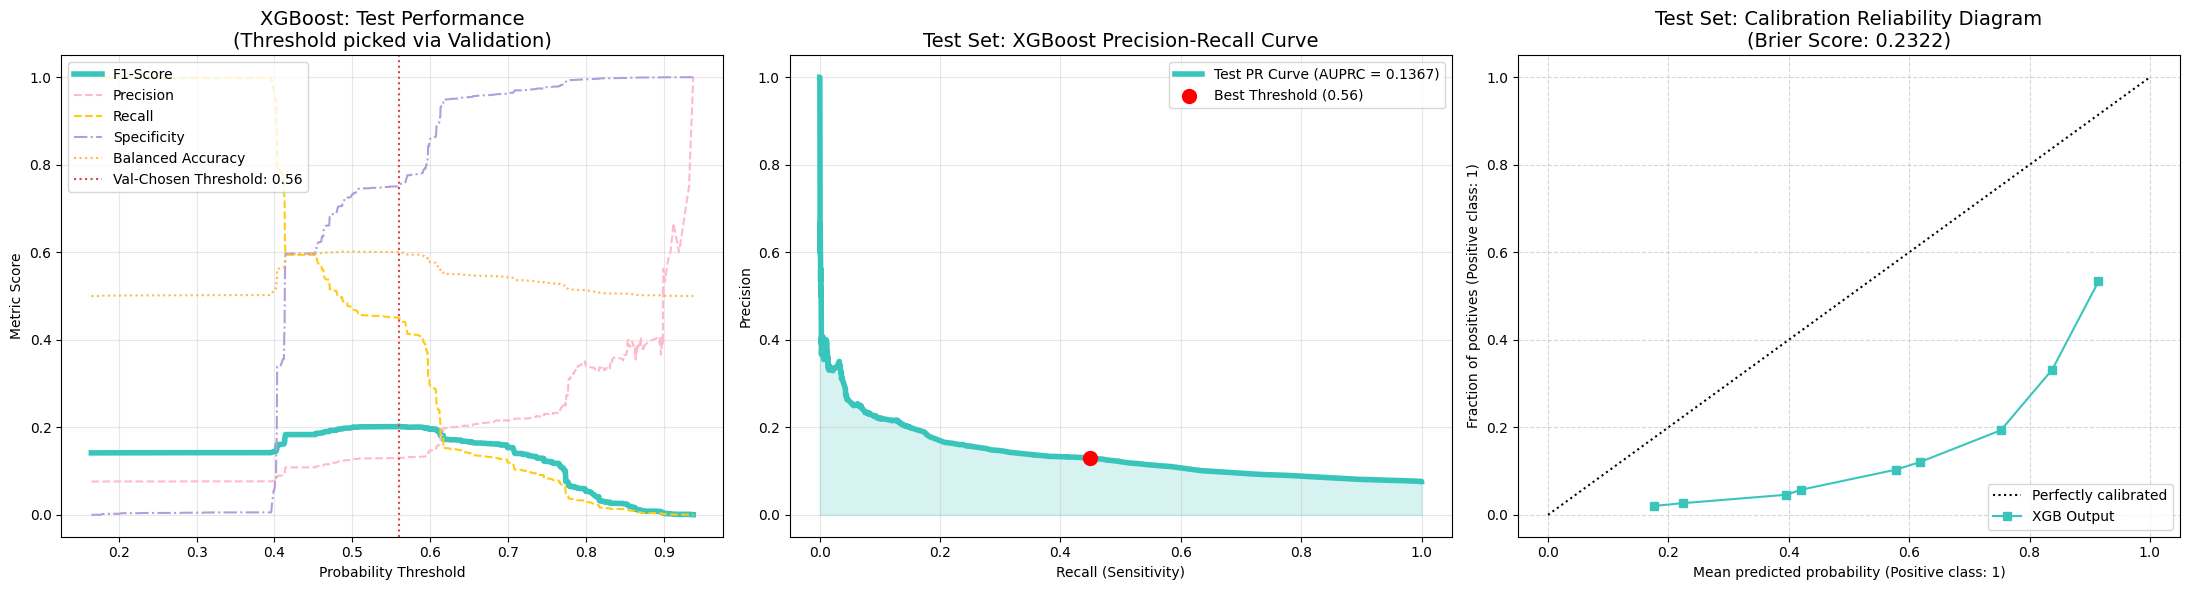

In [25]:
# ---------------------------------------------------------
# STEP 4: PREPARE PLOTTING METRICS (ON TEST SET)
# ---------------------------------------------------------
precision_xgb, recall_xgb, pr_thresholds_xgb = precision_recall_curve(y_test_processed, xgb_probs_test)
test_f1s = 2 * (precision_xgb * recall_xgb) / (precision_xgb + recall_xgb + 1e-8)
auprc_xgb = average_precision_score(y_test_processed, xgb_probs_test)

# Calculate Specificity and Balanced Accuracy across all thresholds for Plot 1
test_specificity = []
test_bal_acc = []

for t in pr_thresholds_xgb:
    preds = (xgb_probs_test >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_processed, preds).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0 
    
    test_specificity.append(spec)
    test_bal_acc.append((spec + sens) / 2)

# ---------------------------------------------------------
# STEP 5: PLOT ALL 3 GRAPHS (1x3 GRID)
# ---------------------------------------------------------
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

# --- PLOT 1: Threshold vs Metrics ---
ax1.plot(pr_thresholds_xgb, test_f1s[:-1], label='F1-Score', color='#39C5BB', linewidth=4)
ax1.plot(pr_thresholds_xgb, precision_xgb[:-1], label='Precision', color='#FFBACC', linestyle='--')
ax1.plot(pr_thresholds_xgb, recall_xgb[:-1], label='Recall', color='#FFCC11', linestyle='--')
ax1.plot(pr_thresholds_xgb, test_specificity, label='Specificity', color='#B39DDB', linestyle='-.')
ax1.plot(pr_thresholds_xgb, test_bal_acc, label='Balanced Accuracy', color='#FFB74D', linestyle=':')

ax1.axvline(miku_threshold, color='#DD4444', linestyle=':', 
            label=f'Val-Chosen Threshold: {miku_threshold:.2f}')

ax1.set_title("XGBoost: Test Performance\n(Threshold picked via Validation)", fontsize=14)
ax1.set_xlabel("Probability Threshold")
ax1.set_ylabel("Metric Score")
ax1.legend()
ax1.grid(alpha=0.3)

# --- PLOT 2: Precision-Recall Curve ---
ax2.plot(recall_xgb, precision_xgb, color='#39C5BB', linewidth=4, label=f'Test PR Curve (AUPRC = {auprc_xgb:.4f})')
ax2.fill_between(recall_xgb, 0, precision_xgb, color='#39C5BB', alpha=0.2)

idx_xgb = np.argmin(np.abs(pr_thresholds_xgb - miku_threshold))
ax2.scatter(recall_xgb[idx_xgb], precision_xgb[idx_xgb], color='red', s=100, zorder=5, label=f'Actual Operating Point ({miku_threshold:.2f})')

ax2.set_title("Test Set: XGBoost Precision-Recall Curve", fontsize=14)
ax2.set_xlabel("Recall (Sensitivity)")
ax2.set_ylabel("Precision")
ax2.legend()
ax2.grid(alpha=0.3)

# --- PLOT 3: Calibration Curve ---
CalibrationDisplay.from_predictions(
    y_test_processed, 
    xgb_probs_test, 
    n_bins=10, 
    name="XGB Output",
    ax=ax3,
    color='#39C5BB'
)
ax3.set_title(f"Test Set: Calibration Reliability Diagram\n(Brier Score: {brier_test:.4f})", fontsize=14)
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# SHAP

In [26]:
import shap

# 1. Initialize the Tree Explainer for XGBoost
explainer_xgb = shap.TreeExplainer(best_xgb_model)
shap_vals_xgb = explainer_xgb.shap_values(X_test_processed)

# XGBoost typically returns a single 2D array for binary classification,
# but we add a safety check just in case your specific version returns a list!
if isinstance(shap_vals_xgb, list):
    shap_raw_xgb = shap_vals_xgb[1]
else:
    shap_raw_xgb = shap_vals_xgb

# Put them in a DataFrame for easy grouping
shap_df_xgb = pd.DataFrame(shap_raw_xgb, columns=X_test_processed.columns)
grouped_shap_df_xgb = shap_df_xgb.copy()

# 2. Define the exact prefixes of your One-Hot Encoded columns
categorical_prefixes = ['cat__Sex','cat__Age_Group','cat__Transmission',
                        'cat__Healthcare_Access_Friction','cat__Civil_Status','cat__OFW_Status','cat__Chemsex_Engagement',
                        'cat__Alcohol_Sex_Risk','cat__PrEP_Awareness','cat__Transactional_Sex','cat__STI_BBV_CoInfection_Any']

# 3. Stitch the dummy columns back together!
for prefix in categorical_prefixes:
    # Find all columns that start with this prefix
    dummy_cols = [col for col in X_test_processed.columns if col.startswith(f"{prefix}_")]

    if len(dummy_cols) > 0:
        # Sum the dummy parts to get the total category importance
        grouped_shap_df_xgb[prefix] = shap_df_xgb[dummy_cols].sum(axis=1)
        # Drop the diluted dummy columns
        grouped_shap_df_xgb.drop(columns=dummy_cols, inplace=True)

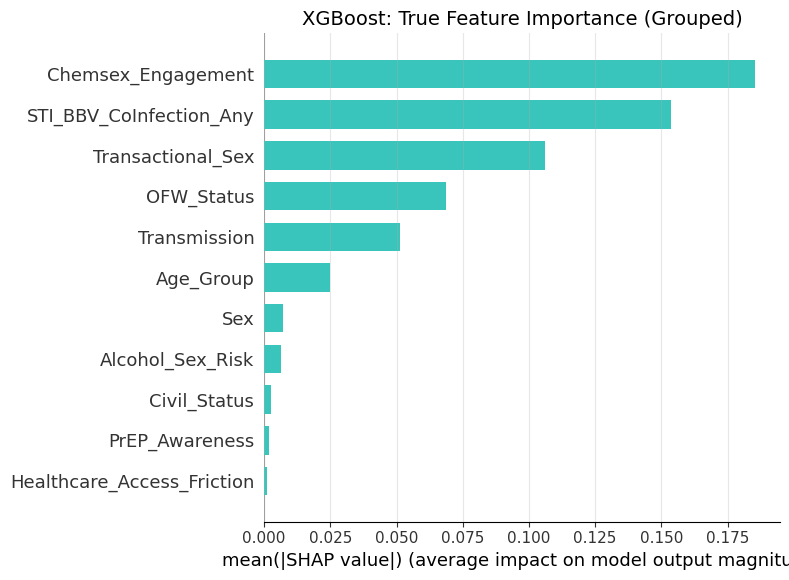

In [27]:
# 4. Plot the Global Feature Importance (Miku Teal!)
plt.figure(figsize=(12, 8))
plt.title(f"XGBoost: True Feature Importance (Grouped)", fontsize=14)

shap.summary_plot(
    grouped_shap_df_xgb.values,
    feature_names=grouped_shap_df_xgb.columns,
    plot_type="bar",
    color="#39C5BB", #turqoise
    show=False
)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## TOP 10 INDIVIDUAL FEATURES 

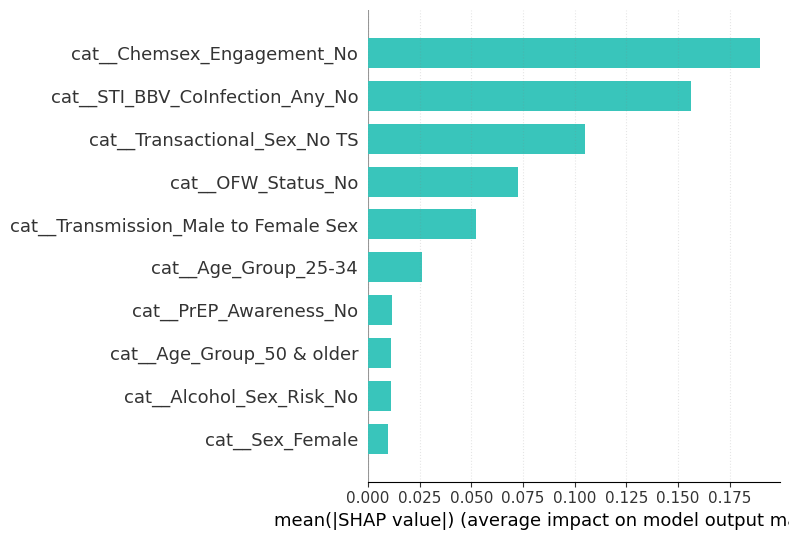

In [17]:
explainer_xgb = shap.TreeExplainer(best_xgb_model)
shap_vals_xgb = explainer_xgb.shap_values(X_test_processed)

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_vals_xgb,
    features=X_test_processed,
    feature_names=X_test_processed.columns,
    plot_type="bar",                      
    color="#39C5BB",
    max_display=10,
    show=False
)

# Optional: Adding a subtle grid
plt.grid(axis='x', color='gray', alpha=0.2, linestyle=':')
plt.tight_layout()
plt.show()


## Beeswarm

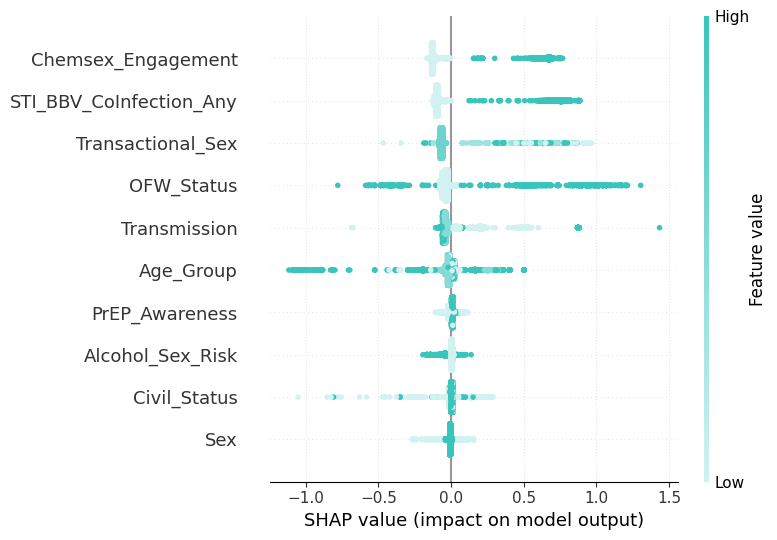

In [12]:
import matplotlib.colors as mcolors
plt.figure(figsize=(10, 6))
miku_cmap = mcolors.LinearSegmentedColormap.from_list("miku_gradient", ["#D1F2F0", "#39C5BB"])
shap.summary_plot(
    shap_vals_xgb,
    features=X_test_processed,
    feature_names=X_test_processed.columns,
    plot_type="dot",                        # Beeswarm style
    cmap=miku_cmap,
    max_display=10,                         # Top 10 only
    show=False
)

# Optional: Adding a subtle grid
plt.grid(axis='x', color='gray', alpha=0.2, linestyle=':')
plt.tight_layout()
plt.show()

# SAVING THE MODEL (RUN MO TO YA IF YOU THINK MAGANDA RESULT PARA MASAVE)

In [29]:
import json
import joblib

print("Saving model artifacts...")

# 1. Save the trained XGBoost model natively (JSON format is highly recommended)
best_xgb_model.save_model("best_xgb_model.json")
print("✓ XGBoost model saved as 'best_xgb_model.json'")

# 2. Save the optimal threshold into a small config file
threshold_config = {"miku_threshold": float(miku_threshold)}
with open("xgb_threshold_config.json", "w") as f:
    json.dump(threshold_config, f)
print("✓ Optimal threshold saved as 'xgb_threshold_config.json'")

# 3. Save the OrdinalEncoder (assuming your encoder variable is named 'encoder')
joblib.dump(encoder, "ordinal_encoder.joblib")
print("✓ Ordinal Encoder saved as 'ordinal_encoder.joblib'")

print("All artifacts saved successfully!")

Saving model artifacts...
✓ XGBoost model saved as 'best_xgb_model.json'
✓ Optimal threshold saved as 'xgb_threshold_config.json'
✓ Ordinal Encoder saved as 'ordinal_encoder.joblib'
All artifacts saved successfully!


# RELOADING

In [ ]:
import json
import joblib
import pandas as pd
import xgboost as xgb

print("Loading model artifacts...")

# 1. Load the Preprocessor
loaded_encoder = joblib.load("ordinal_encoder.joblib")

# 2. Load the Threshold
with open("xgb_threshold_config.json", "r") as f:
    loaded_config = json.load(f)
loaded_threshold = loaded_config["miku_threshold"]

# 3. Load the XGBoost Model
loaded_xgb_model = xgb.XGBClassifier()
loaded_xgb_model.load_model("best_xgb_model.json")

print(f"✓ Everything loaded! Operating Threshold: {loaded_threshold:.4f}")

# ==========================================
# HOW TO PREDICT ON BRAND NEW DATA
# ==========================================
# Assuming 'new_patient_data' is a pandas DataFrame with raw string categories

# A. Transform strings to integers using the loaded encoder
# new_data_encoded = loaded_encoder.transform(new_patient_data)
# new_data_df = pd.DataFrame(new_data_encoded, columns=new_patient_data.columns)

# B. Convert to Native Categorical exactly like training
# new_data_xgb = new_data_df.astype(int).astype('category')

# C. Get Probabilities
# new_probs = loaded_xgb_model.predict_proba(new_data_xgb)[:, 1]

# D. Apply the Golden Threshold!
# final_predictions = (new_probs >= loaded_threshold).astype(int)